In [138]:
import glob
import os

import pandas as pd
import numpy as np

import tifffile as tf
from tifffile import imread
from tifffile import imwrite
import skimage
from skimage.util import compare_images
from skimage import io, color, measure

import matplotlib.pyplot as plt
import matplotlib

%load_ext autoreload
%autoreload 2
%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [90]:
# Import masks

mask_cell_dir = '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230223/D21/ROIs/Whole_cell/ROIs_as_mask_BIOP'
mask_cell_path = os.path.join(mask_cell_dir,'*.tif') 
mask_cell_files = glob.glob(mask_cell_path)

mask_nucleus_dir = '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230223/D21/ROIs/Nucleus/ROIs_as_mask_BIOP'
mask_nucleus_path = os.path.join(mask_nucleus_dir,'*.tif') 
mask_nucleus_files = glob.glob(mask_nucleus_path)


In [91]:
# Read images into list

mask_cell = []
mask_nucleus = []

for file in mask_cell_files:
    image = imread(file)
    mask_cell.append(image)

for file in mask_nucleus_files:
    image = imread(file)
    mask_nucleus.append(image)

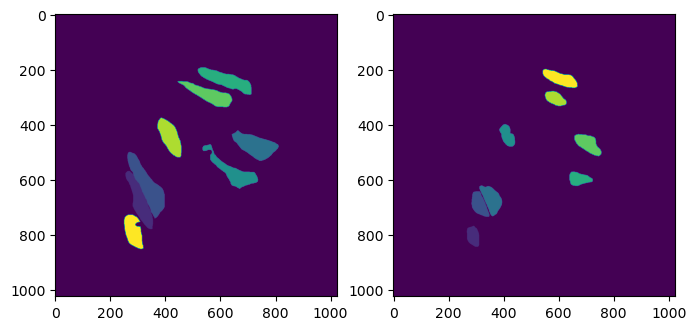

In [120]:
# Plot whole cell and nucleus mask side by side

fig, ax = plt.subplots(1, 2, figsize = (8,4))
ax[0].imshow(mask_cell[3])
ax[1].imshow(mask_nucleus[3])

In [118]:
# Make binary images from masks to be able to substract them from one another

mask_cell_binary = []
mask_nucleus_binary = []

for image in mask_cell:
    if image.ndim == 3:
        image = color.rgb2gray(image) # converts the image to greyscale
    
    threshold_value = 0.5 # pixel value threshold to determine which pixels will be 1 and which ones 0

    binary_mask = np.where(image > threshold_value, 1, 0) # conversion to binary image
    mask_cell_binary.append(binary_mask)

for image in mask_nucleus:
    if image.ndim == 3:
        image = color.rgb2gray(image) # converts the image to greyscale
    
    threshold_value = 0.5 # pixel value threshold to determine which pixels will be 1 and which ones 0

    binary_mask = np.where(image > threshold_value, 1, 0) # conversion to binary image
    mask_nucleus_binary.append(binary_mask)

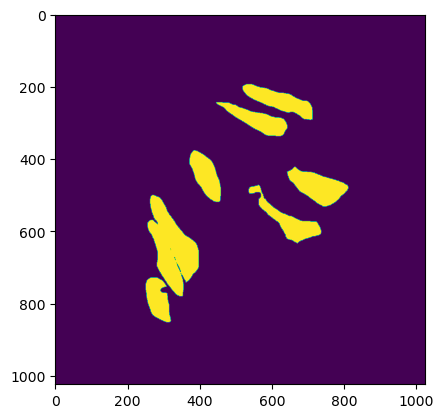

In [119]:
# Plot binary mask

plt.imshow(mask_cell_binary[3])

In [121]:
# Substract nucleus mask from cell mask and store as binary cytoplasm mask

mask_cytoplasm_binary = []

for cell, nucleus in zip (mask_cell_binary, mask_nucleus_binary):
    image = skimage.util.compare_images(cell, nucleus)
    mask_cytoplasm_binary.append(image)

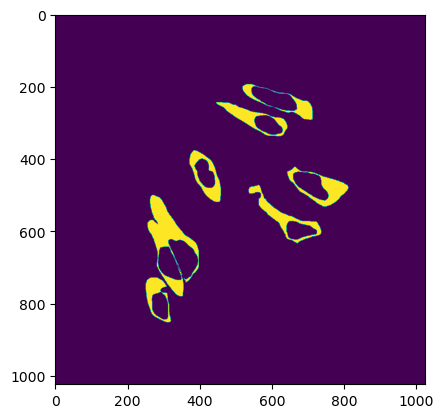

In [132]:
# Plot binary cytoplasm mask

plt.imshow(mask_cytoplasm_binary[3])

In [133]:
# Save cytoplasm masks

mask_cytoplasm_dir = '/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230223/D21/ROIs/Cytoplasm/ROIs_as_mask_BIOP'


In [77]:
import scipy.misc
import tifffile as tf

In [137]:
for img, tiff_file in zip(mask_cytoplasm_binary, mask_cell_files):
    # Extract the original file name without the extension
    file_name = os.path.splitext(os.path.basename(tiff_file))[0]
    print(file_name)
    
    
    # Define the output file path
    output_file = os.path.join(mask_cytoplasm_dir, file_name)
    print(output_file)
    shape = img.shape
    dtype = img.dtype

    # Save the manipulated image as TIFF
    tf.imwrite(output_file, img)

100tp_561-100-50ms-1000g_16_conf561_merged_ROIs
/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230223/D21/ROIs/Cytoplasm/ROIs_as_mask_BIOP/100tp_561-100-50ms-1000g_16_conf561_merged_ROIs
100tp_561-100-50ms-1000g_15_conf561_merged_ROIs
/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230223/D21/ROIs/Cytoplasm/ROIs_as_mask_BIOP/100tp_561-100-50ms-1000g_15_conf561_merged_ROIs
100tp_561-100-50ms-1000g_18_conf561_merged_ROIs
/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230223/D21/ROIs/Cytoplasm/ROIs_as_mask_BIOP/100tp_561-100-50ms-1000g_18_conf561_merged_ROIs
100tp_561-100-50ms-1000g_4_conf561_merged_ROIs
/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230223/D21/ROIs/Cytoplasm/ROIs_as_mask_BIOP/100tp_561-100-50ms-1000g_4_conf561_merged_ROIs
100tp_561-100-50ms-1000g_8_conf561_merged_ROIs
/Users/abamford/Desktop/TUBB2B-KI_preliminary_analysis/Batch20230223/D21/ROIs/Cytoplasm/ROIs_as_mask_BIOP/100tp_561-100-50ms-1000g_8_conf561_merged